# Setup

In [1]:
import seaborn as sns
import pandas as pd
import random

In [2]:
pd.set_option("display.max_columns", None)

# Data

In [3]:
data = pd.read_csv("data/data.csv")

data = data.rename(columns={"id": "pmid"})
data = data.drop(['Unnamed: 0'], axis = 1)

In [4]:
data.shape

(63669, 113)

# Data description

In [5]:
data.columns.tolist()

['datatype',
 'country',
 'institute',
 'eid',
 'tr',
 'eid_tr',
 'pmid',
 'rep',
 'app_start',
 'meas_start',
 'year',
 'interval',
 'dt',
 'ct',
 'e_cum',
 'delta_e_cum',
 'j_nh3',
 'air_temp',
 'wind_2m',
 'rain_rate',
 'rain_cum',
 'meas_tech',
 'app_method',
 'incorp',
 'time_incorp',
 'furrow_z',
 'fer_origin',
 'fer_forme',
 'fer_trt1',
 'fer_trt2',
 'fer_trt3',
 'fer_ph',
 'fer_dm',
 'tan_app',
 'app_rate',
 'soil_type',
 'soil_water',
 'soil_ph',
 'soil_dens',
 'soil_oc',
 'soil_clay',
 'soil_sand',
 'soil_silt',
 'crop',
 'crop_z',
 'till',
 'air_temp_ind',
 'wind_2m_ind',
 'fer_ph_ind',
 'fer_dm_ind',
 'soil_water_ind',
 'soil_ph_ind',
 'soil_dens_ind',
 'soil_oc_ind',
 'soil_clay_ind',
 'soil_sand_ind',
 'soil_silt_ind',
 'crop_z_ind',
 'time_incorp_ind',
 'furrow_z_ind',
 'dt_origin',
 'ct_origin',
 'e_cum_origin',
 'delta_e_cum_origin',
 'j_nh3_origin',
 'air_temp_origin',
 'wind_2m_origin',
 'rain_rate_origin',
 'rain_cum_origin',
 'time_incorp_origin',
 'furrow_z_origin

**Description des variables :**

- datatype : field / lab
- eid : experience identification code
- tr : treatment, an integer corresponding to a unique combination of other variables such as application method, application rate, ...
- eid_tr : (experience, treatment) identification code
- pmid : plot (measurement) identification code, each pmid correspond to one and only one curve
- rep : repetition number
- app_start : date of fertilizer application
- meas_start : date of measurement start
- interval : interval number (each measurement emissions correspond to a time interval)
  
- dt : length of the interval
- ct : cumlative time
- e_cum : cumulative emissions
- delta_e_cum : absolute emissions
- j_nh3 : flux, j_nh3 = delta_e_cum / dt
- air_temp, wind_2m, rain_rate, rain_cum : temperature, wind, rain, cumulative rain
- meas_tech : measurment method (micro met, wt, Caract'Air, chamber, cps)
- app_method : application method
- incorp : type of incorporation (none / shallow / deep)
- time_incorp : if incorp != none, time of incorporation
- furrow_z : depth of incoporation
- fer_origin : fertilizer origin (cat / pig / ...)
- fer_forme : fertilizer forme (liquid / pasty / solid)
- fer_trt1 2 3 : fertilizer treatment (e.g. acidification, separation, ...)
- fer_ph : pH
- fer_dm : dry matter content
- tan app : Total ammoniacal nitrogen rate (kg/ha)
- app_rate : fertilizer application rate (t/ha)
- soil_type/water/ph/dens/oc/clay/sand/silt : ...
- crop, crop_z : crop, crop height
- till : yes / no

**Note 1** the variables dt, ct, e_cum, delta_e_cum, ... till have been transformed. Categorical variables have been converted to integers and continous variables have been normalized.

**Note 2** original values are stored in the variables with suffix '_origin'.

**Note 3** varaibles with suffix '_ind' indicate wheter the original value was either known, NA or NC (not concerned)

**Note 4** variables with suffix '_origin_2' are continuous variables that have not been normalized, and where NA values have been replace with 1000 and NC values have been replace with -1000.


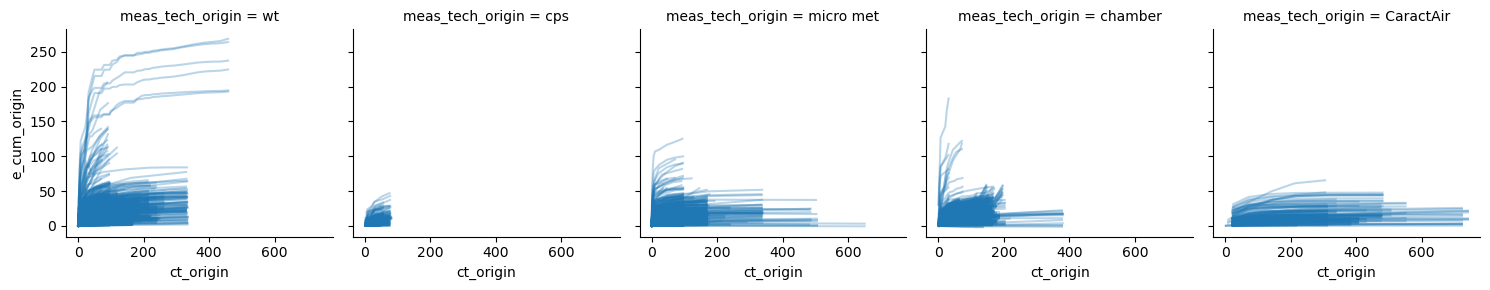

In [6]:
g = sns.FacetGrid (data, col = "meas_tech_origin", col_wrap = 5)
g.map_dataframe (sns.lineplot, x = "ct_origin", y = "e_cum_origin", units = "pmid", estimator = None, alpha = 0.3)

In [7]:
data[data['fer_origin_origin'] == "cat"][["eid_tr", "fer_origin_origin", "meas_tech_origin"]].drop_duplicates().value_counts (["meas_tech_origin", "fer_origin_origin"])

meas_tech_origin  fer_origin_origin
micro met         cat                  438
wt                cat                  169
chamber           cat                   50
cps               cat                   30
CaractAir         cat                   14
Name: count, dtype: int64

## Measurement heterogeneity

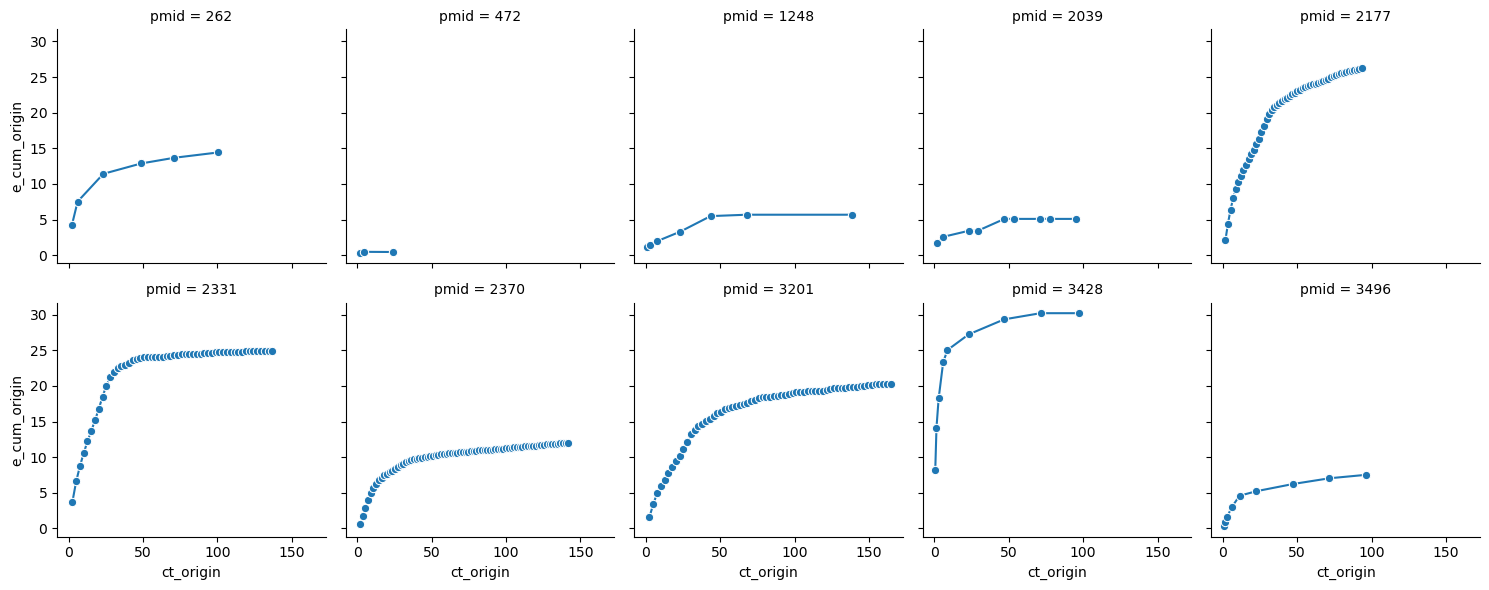

In [8]:
pmids = data ['pmid'].unique().tolist()

random.seed (1)
data_tmp = data [data ['pmid'].isin (random.sample (pmids, 10))]

g = sns.FacetGrid (data_tmp, col = "pmid", col_wrap = 5)
g.map_dataframe (sns.lineplot, x = "ct_origin", y = "e_cum_origin", units = "pmid", estimator = None, marker = 'o')

## An experiment example

In [9]:
data [data ['eid'] == 211][['institute_origin', 'tr', 'pmid', 'meas_tech_origin', 'app_method_origin', 'fer_origin_origin', 'tan_app_origin', 'fer_ph_origin']].drop_duplicates()

,institute_origin,tr,pmid,meas_tech_origin,app_method_origin,fer_origin_origin,tan_app_origin,fer_ph_origin
13993,ARDC,2,1121,micro met,cs,cat,87.0,7.3
13998,ARDC,2,1122,micro met,cs,cat,80.0,7.3
14003,ARDC,2,1123,micro met,cs,cat,77.0,7.3
14008,ARDC,1,1124,micro met,bc,cat,79.0,7.3
14013,ARDC,1,1125,micro met,bc,cat,70.0,7.3
14018,ARDC,1,1126,micro met,bc,cat,82.0,7.3


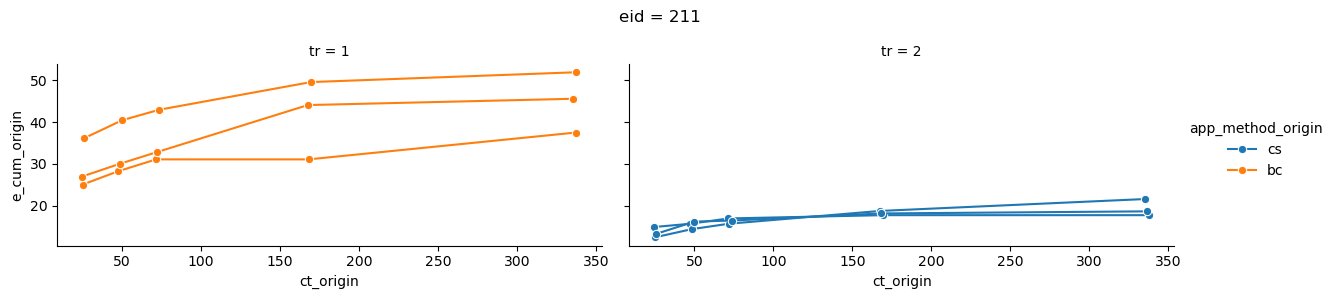

In [10]:
data_tmp = data [data ['eid'] == 211]

g = sns.FacetGrid (data_tmp, col = "tr", col_wrap = 2, hue = "app_method_origin", height = 3, aspect = 2)
g.map_dataframe (sns.lineplot, x = "ct_origin", y = "e_cum_origin", units = "pmid", estimator = None, marker = 'o')

g.add_legend()
g.figure.suptitle("eid = 211")
g.figure.subplots_adjust(top = 0.8)

# End